In [1]:
import numpy as np
from fractions import Fraction
import copy
import nashpy as nash
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def normalize_matrices(A, B):
    C = min(A.min(), B.min())
    
    if C <= 0:
        return A - C + 1, B - C + 1
    return A, B

In [3]:
def print_dict(mat, mat_name):
    print(mat_name)
    m, n = mat.shape
    for y in range(m):
        line = "x" + str(mat[y, 0]) + " = " + str(mat[y, 1])
        for x in range(2, n):
            if mat[y, x] != 0:
                line += " + " + str(mat[y, x]) + " x" + str(x - 1)
        print(line)

In [4]:
def create_polytopes_dictionnaries(A, B):
    m, n = A.shape
    
    A_dict = np.hstack((np.array([np.arange(1, m + 1)]).T, np.array([np.ones(m)]).T, np.zeros([m, m]), -A))
    B_dict = np.hstack((np.array([np.arange(m + 1, n + m + 1)]).T, np.array([np.ones(n)]).T, -B.T, np.zeros([n, n])))

    A_dict = np.vectorize(Fraction)(A_dict)
    B_dict = np.vectorize(Fraction)(B_dict)

    return A_dict, B_dict

In [5]:
def drop_label(A_dict, B_dict, choosen_label, last_dropped):
    # print(f"Trying to drop {choosen_label} with {last_dropped} last dropped.")
    A_dict = copy.deepcopy(A_dict)
    B_dict = copy.deepcopy(B_dict)

    m, n = A_dict.shape[0], B_dict.shape[0]

    row_index = np.argmin(B_dict[:, choosen_label + 1] / (B_dict[:, 1] + 0.00000001))
    new_label = int(B_dict[row_index, 0])

    working_dict = B_dict

    if new_label == last_dropped:
        row_index = np.argmin(A_dict[:, choosen_label + 1] / (A_dict[:, 1] + 0.00000001))
        new_label = int(A_dict[row_index, 0])

        working_dict = A_dict
    
    min_factor = working_dict[row_index, choosen_label + 1]

    # Change the row in question
    working_dict[row_index, choosen_label + 1] = 0
    working_dict[row_index, new_label + 1] = -1
    for i in range(1, m + n + 2):
        working_dict[row_index, i] /= -min_factor

    working_dict[row_index, 0] = choosen_label

    # Change the other rows
    for y in range(working_dict.shape[0]):
        if y == row_index:
            continue

        factor = working_dict[y, choosen_label + 1]
        for x in range(1, m + n + 2):
            if x == choosen_label + 1:
                working_dict[y, x] = 0
            else:
                working_dict[y, x] += factor * working_dict[row_index, x]

    # print(f"{new_label=}")
    return A_dict, B_dict, new_label


In [6]:
def find_proba(A_dict, B_dict):
    m, n = A_dict.shape[0], B_dict.shape[0]

    player1_proba, player2_proba = np.zeros(m), np.zeros(n)

    for y in range(n):
        if B_dict[y, 0] in range(1, m + 1):
            player1_proba[B_dict[y, 0] - 1] = B_dict[y, 1]

    for y in range(m):
        if A_dict[y, 0] in range(m + 1, m + n + 1):
            player2_proba[A_dict[y, 0] - m - 1] = A_dict[y, 1]
    
    return player1_proba / player1_proba.sum(), player2_proba / player2_proba.sum()


In [7]:
def find_nash_equilibrium(A_dict, B_dict, initial_drop):
    last_dropped = None
    A_dict_final, B_dict_final, new_l = drop_label(A_dict, B_dict, initial_drop, last_dropped)
    last_dropped = initial_drop

    paths = []
    while new_l != initial_drop:
        paths.append(find_proba(A_dict_final, B_dict_final))
        # print_dict(A_dict_final, "A_dict_final")
        # print_dict(B_dict_final, "B_dict_final")
        A_dict_final, B_dict_final, tmp_new_l = drop_label(A_dict_final, B_dict_final, new_l, last_dropped)
        last_dropped = new_l
        new_l = tmp_new_l

    paths.append(find_proba(A_dict_final, B_dict_final))
    
    return A_dict_final, B_dict_final, paths


In [8]:
def find_nash_proba(A, B):
    A_normalized, B_normalized = normalize_matrices(A, B)

    A_dict, B_dict = create_polytopes_dictionnaries(A_normalized, B_normalized)

    # print_dict(A_dict, "A_dict")
    # print_dict(B_dict, "B_dict")

    A_dict_final, B_dict_final, paths = find_nash_equilibrium(A_dict, B_dict, 1)

    # print_dict(A_dict_final, "A_dict_final")
    # print_dict(B_dict_final, "B_dict_final")

    p1_proba, p2_proba = find_proba(A_dict_final, B_dict_final)

    # print(p1_proba)
    # print(p2_proba)

    game = nash.Game(A, B)
    solutions = list(game.support_enumeration())

    for solution in solutions:
        if (solution[0] == p1_proba).all() and (solution[1] == p2_proba).all():
            print("Success !!!")
    
    return p1_proba, p2_proba, paths

C:\Users\Risto\AppData\Local\Temp\ipykernel_24356\2465639858.py:14: RuntimeWarning: invalid value encountered in divide
  return player1_proba / player1_proba.sum(), player2_proba / player2_proba.sum()
c:\Users\Risto\Documents\Evariste\Ecole\Epita\2025-2026\ProjetNash\.venv\Lib\site-packages\nashpy\algorithms\support_enumeration.py:260: RuntimeWarning: 
An even number of (2) equilibria was returned. This
indicates that the game is degenerate. Consider using another algorithm
to investigate.
                  
  warnings.warn(warning, RuntimeWarning)


Success !!!
[0. 1. 0.]
[0. 1. 0.]
[[3 0 1]
 [1 2 0]
 [0 1 4]]
[[1 2 2]
 [2 4 2]
 [0 4 4]]


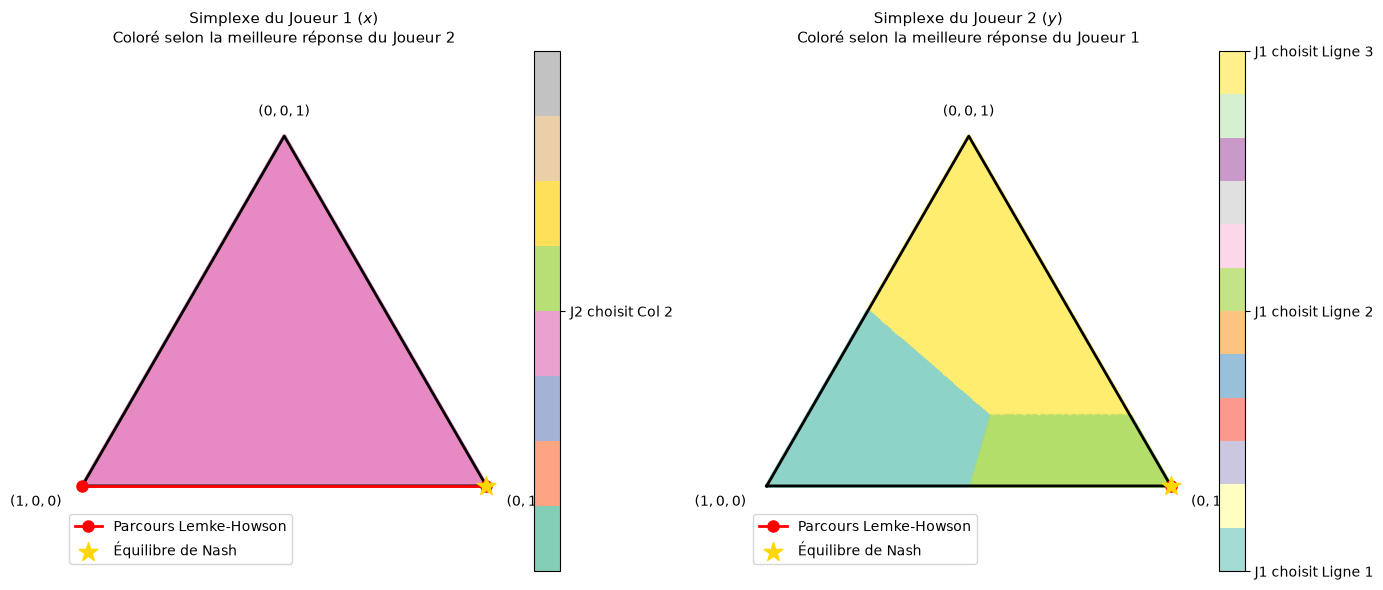

In [126]:
def generate_simplex_grid(resolution=300):
    """ Génère une grille de points sur le simplexe 3D (x1 + x2 + x3 = 1) """
    points = []
    for i in range(resolution + 1):
        for j in range(resolution + 1 - i):
            k = resolution - i - j
            points.append([i / resolution, j / resolution, k / resolution])
    return np.array(points)

def project_to_2d(points):
    """ Projette les coordonnées du simplexe (x1, x2, x3) en coordonnées 2D (X, Y) """
    X = points[:, 1] + 0.5 * points[:, 2]
    Y = (np.sqrt(3) / 2) * points[:, 2]
    return X, Y

def plot_bimatrix_simplexes(A, B, x_path=None, y_path=None):
    """
    Trace les régions de meilleure réponse pour un jeu bi-matrice 3x3.
    A : Matrice de gains du Joueur 1 (3x3)
    B : Matrice de gains du Joueur 2 (3x3)
    """
    # Génération des points du simplexe
    points = generate_simplex_grid(resolution=300)
    X, Y = project_to_2d(points)
    
    # --- 1. Meilleures réponses du Joueur 2 face aux stratégies mixtes x du Joueur 1 ---
    # Le gain espéré du Joueur 2 pour la colonne j est (B.T @ x)_j
    payoffs_J2 = points @ B  # Équivalent à x @ B (taille N x 3)
    br_J2 = np.argmax(payoffs_J2, axis=1) # Colonne optimale du J2

    # --- 2. Meilleures réponses du Joueur 1 face aux stratégies mixtes y du Joueur 2 ---
    # Le gain espéré du Joueur 1 pour la ligne i est (A @ y)_i
    payoffs_J1 = points @ A.T  # Équivalent à y @ A.T (taille N x 3)
    br_J1 = np.argmax(payoffs_J1, axis=1) # Ligne optimale du J1

    # Configuration de la figure (2 graphiques côte à côte)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Graphique 1 : Simplexe du Joueur 1 ---
    sc1 = axes[0].scatter(X, Y, c=br_J2, cmap='Set2', s=4, alpha=0.8)
    axes[0].set_title("Simplexe du Joueur 1 ($x$)\nColoré selon la meilleure réponse du Joueur 2", fontsize=11)
    cbar1 = plt.colorbar(sc1, ax=axes[0], ticks=[0, 1, 2])
    cbar1.ax.set_yticklabels(['J2 choisit Col 1', 'J2 choisit Col 2', 'J2 choisit Col 3'])
    
    # --- Graphique 2 : Simplexe du Joueur 2 ---
    sc2 = axes[1].scatter(X, Y, c=br_J1, cmap='Set3', s=4, alpha=0.8)
    axes[1].set_title("Simplexe du Joueur 2 ($y$)\nColoré selon la meilleure réponse du Joueur 1", fontsize=11)
    cbar2 = plt.colorbar(sc2, ax=axes[1], ticks=[0, 1, 2])
    cbar2.ax.set_yticklabels(['J1 choisit Ligne 1', 'J1 choisit Ligne 2', 'J1 choisit Ligne 3'])
    
    # Décoration des deux simplexes
    triangle_x = [0, 1, 0.5, 0]
    triangle_y = [0, 0, np.sqrt(3)/2, 0]
    
    for ax in axes:
        ax.plot(triangle_x, triangle_y, 'k-', lw=2)
        ax.text(-0.05, -0.05, '$(1,0,0)$', fontsize=10, ha='right')
        ax.text(1.05, -0.05, '$(0,1,0)$', fontsize=10, ha='left')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, '$(0,0,1)$', fontsize=10, ha='center')
        ax.axis('equal')
        ax.axis('off')

    if x_path is not None:
        X_path, Y_path = project_to_2d(x_path)

        axes[0].plot(X_path, Y_path, 'r-o', lw=2, markersize=8, label='Parcours Lemke-Howson')
        axes[0].scatter(X_path[-1], Y_path[-1], color='gold', s=200, marker='*', zorder=5, label='Équilibre de Nash')
        axes[0].legend()
    
    if y_path is not None:
        X_path, Y_path = project_to_2d(y_path)

        axes[1].plot(X_path, Y_path, 'r-o', lw=2, markersize=8, label='Parcours Lemke-Howson')
        axes[1].scatter(X_path[-1], Y_path[-1], color='gold', s=200, marker='*', zorder=5, label='Équilibre de Nash')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# A = np.random.randint(1, 10, size=[3, 3])
# B = np.random.randint(1, 10, size=[3, 3])

A = np.array([
    [3, 0, 1],
    [1, 2, 0],
    [0, 1, 4]
])

B = np.array([
    [1, 2, 2],
    [2, 4, 2],
    [0, 4, 4]
])

p1_proba, p2_proba, paths = find_nash_proba(A, B)
print(p1_proba)
print(p2_proba)

x_path = []
y_path = []

switch_constant = 0 if np.isnan(paths[0][0]).any() else 1
for i in range(len(paths)):
    if i % 2 == switch_constant:
        y_path.append(paths[i][1])
    else:
        x_path.append(paths[i][0])

x_path = np.array(x_path)
y_path = np.array(y_path)

print(A)
print(B)

plot_bimatrix_simplexes(A, B, x_path=x_path, y_path=y_path)

C:\Users\Risto\AppData\Local\Temp\ipykernel_24356\2465639858.py:14: RuntimeWarning: invalid value encountered in divide
  return player1_proba / player1_proba.sum(), player2_proba / player2_proba.sum()


Success !!!
[1. 0. 0. 0.]
[0. 0. 0. 1.]
[[9 4 7 8]
 [7 2 2 3]
 [3 8 5 7]
 [7 2 4 8]]
[[8 4 8 9]
 [7 9 4 1]
 [9 2 5 3]
 [6 3 2 2]]


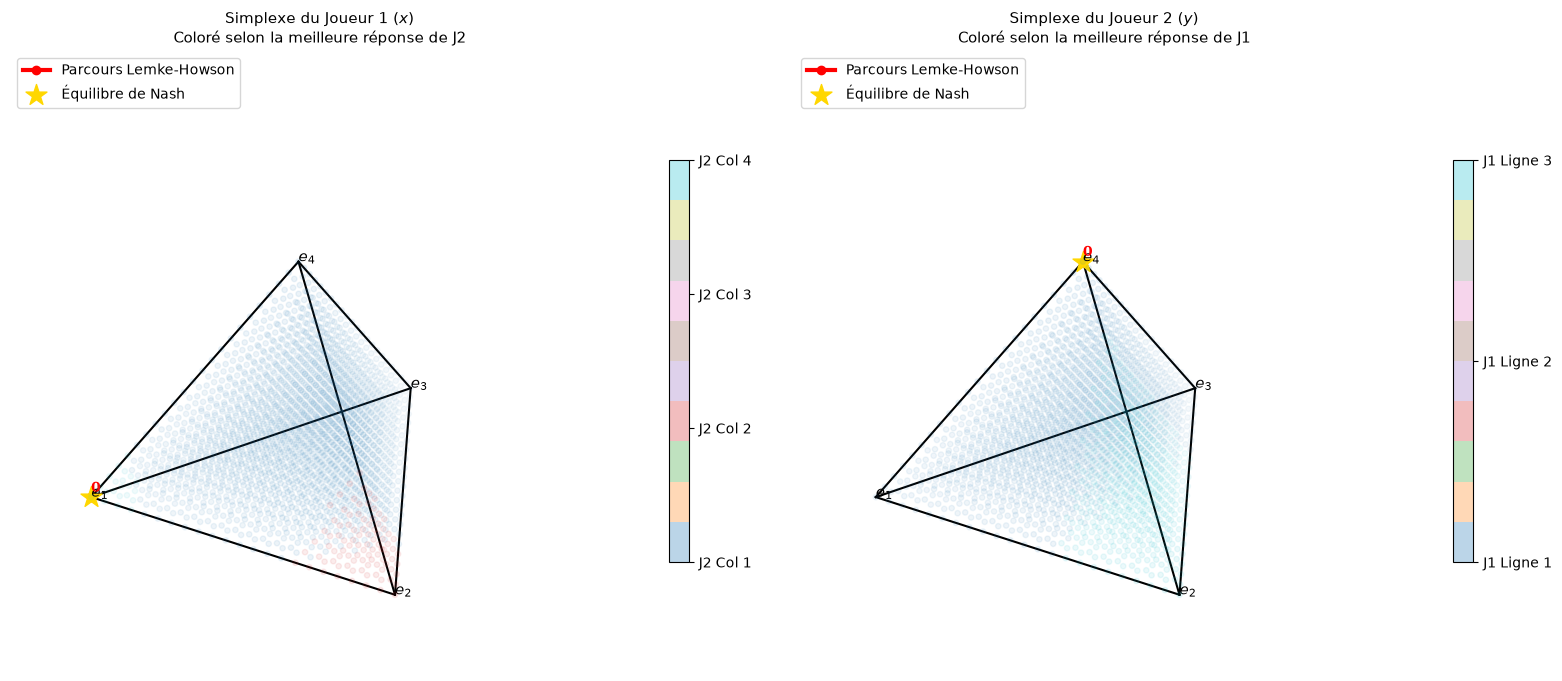

In [127]:
def generate_simplex_grid_3d(resolution=25):
    """
    Génère une grille de points dans le simplexe 4D (x1 + x2 + x3 + x4 = 1)
    """
    points = []
    for i in range(resolution + 1):
        for j in range(resolution + 1 - i):
            for k in range(resolution + 1 - i - j):
                l = resolution - i - j - k
                points.append([i / resolution, j / resolution, k / resolution, l / resolution])
    return np.array(points)

def project_to_tetrahedron(points):
    """
    Projette un point 4D (x1, x2, x3, x4) vers des coordonnées 3D (X, Y, Z)
    en plaçant les 4 sommets sur un tétraèdre régulier.
    """
    # Sommets d'un tétraèdre régulier
    vertices = np.array([
        [0, 0, 0],
        [1, 0, 0],
        [0.5, np.sqrt(3)/2, 0],
        [0.5, np.sqrt(3)/6, np.sqrt(2/3)]
    ])
    # Combinaison convexe : X_3d = sum(x_i * V_i)
    return points @ vertices

def plot_bimatrix_simplexes_4x4(A, B, x_path=None, y_path=None):
    """
    Trace les régions de meilleure réponse pour un jeu bi-matrice 4x4 dans un tétraèdre 3D.
    A : Matrice de gains du Joueur 1 (4x4)
    B : Matrice de gains du Joueur 2 (4x4)
    """
    # 1. Génération des points du simplexe 4D et projection 3D
    points = generate_simplex_grid_3d(resolution=22) # Résolution adaptée pour la 3D
    pts_3d = project_to_tetrahedron(points)
    
    # 2. Meilleures réponses
    # Pour J1 : meilleure réponse de J2 via (points @ B)
    br_J2 = np.argmax(points @ B, axis=1)
    
    # Pour J2 : meilleure réponse de J1 via (points @ A.T)
    br_J1 = np.argmax(points @ A.T, axis=1)

    # 3. Figure 3D côte à côte
    fig = plt.figure(figsize=(16, 7))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    # Sommets du tétraèdre
    vertices = np.array([
        [0, 0, 0],
        [1, 0, 0],
        [0.5, np.sqrt(3)/2, 0],
        [0.5, np.sqrt(3)/6, np.sqrt(2/3)]
    ])
    
    # Arêtes du tétraèdre à tracer
    edges = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

    # Function de tracé pour chaque joueur
    def draw_tetrahedron(ax, br_data, title, cbar_labels, path=None):
        # Plot du nuage de points coloré selon les zones de meilleure réponse
        sc = ax.scatter(pts_3d[:,0], pts_3d[:,1], pts_3d[:,2], 
                        c=br_data, cmap='tab10', s=15, alpha=0.3)
        
        # Structure du tétraèdre (arêtes)
        for e in edges:
            ax.plot3D(*zip(vertices[e[0]], vertices[e[1]]), color='black', lw=1.5)
            
        # Labels des sommets
        labels = ['$e_1$', '$e_2$', '$e_3$', '$e_4$']
        for v, label in zip(vertices, labels):
            ax.text(v[0], v[1], v[2], label, fontsize=11, fontweight='bold')

        # Trace du chemin Lemke-Howson si fourni
        if path is not None:
            path_3d = project_to_tetrahedron(path)
            ax.plot3D(path_3d[:,0], path_3d[:,1], path_3d[:,2], 
                      'r-o', lw=3, markersize=6, label='Parcours Lemke-Howson')
            ax.scatter(path_3d[-1,0], path_3d[-1,1], path_3d[-1,2], 
                       color='gold', s=250, marker='*', zorder=5, label='Équilibre de Nash')
            
            # Numérotation des étapes du parcours
            for i, (pX, pY, pZ) in enumerate(path_3d):
                ax.text(pX, pY, pZ + 0.02, f"{i}", color='red', fontweight='bold')
            ax.legend(loc='upper left')

        ax.set_title(title, fontsize=11)
        ax.set_axis_off() # Masquer les axes 3D par défaut
        cbar = fig.colorbar(sc, ax=ax, ticks=[0, 1, 2, 3], shrink=0.6)
        cbar.ax.set_yticklabels(cbar_labels)

    # Affichage pour les deux joueurs
    draw_tetrahedron(ax1, br_J2, 
                     "Simplexe du Joueur 1 ($x$)\nColoré selon la meilleure réponse de J2",
                     ['J2 Col 1', 'J2 Col 2', 'J2 Col 3', 'J2 Col 4'], x_path)
    
    draw_tetrahedron(ax2, br_J1, 
                     "Simplexe du Joueur 2 ($y$)\nColoré selon la meilleure réponse de J1",
                     ['J1 Ligne 1', 'J1 Ligne 2', 'J1 Ligne 3', 'J1 Ligne 4'], y_path)

    plt.tight_layout()
    plt.show()

A = np.random.randint(1, 10, size=[4, 4])
B = np.random.randint(1, 10, size=[4, 4])

p1_proba, p2_proba, paths = find_nash_proba(A, B)
print(p1_proba)
print(p2_proba)

x_path = []
y_path = []

switch_constant = 0 if np.isnan(paths[0][0]).any() else 1
for i in range(len(paths)):
    if i % 2 == switch_constant:
        y_path.append(paths[i][1])
    else:
        x_path.append(paths[i][0])

x_path = np.array(x_path)
y_path = np.array(y_path)

print(A)
print(B)

plot_bimatrix_simplexes_4x4(A, B, x_path=x_path, y_path=y_path)

In [10]:
# =====================================================================
# 1. DUEL COMMERCIAL (Guerre des prix / Duopole)
# =====================================================================
# Hypothèses :
# 2 entreprises A et B proposent 3 niveaux de prix :
#   Stratégie 0 : Prix Élevé (marge maximale)
#   Stratégie 1 : Prix Moyen (compromis)
#   Stratégie 2 : Prix Bas (stratégie agressive d'éviction)

# Gains de l'Entreprise A
A_duel = np.array([
    [5, 2, 1],  # Prix Élevé: cartelle si B fait pareil (5), perd des parts si B baisse les prix (2 ou 1)
    [7, 4, 2],  # Prix Moyen: prend des parts si B fait Prix Élevé (7), modéré face à Prix Bas (2)
    [8, 5, 2]   # Prix Bas: rafle le marché si B est cher (8), mais guerre de prix ruineuse si B fait pareil (2)
])

# Gains de l'Entreprise B
# Le jeu est symétrique : B a la même structure de gains en miroir (A.T)
B_duel = np.array([
    [5, 7, 8],
    [2, 4, 5],
    [1, 2, 2]
])

p1_proba_duel, p2_proba_duel, _ = find_nash_proba(A_duel, B_duel)
print(p1_proba_duel)
print(p2_proba_duel)

Success !!!
[0. 1. 0.]
[0. 0. 1.]


C:\Users\Risto\AppData\Local\Temp\ipykernel_11856\2465639858.py:14: RuntimeWarning: invalid value encountered in divide
  return player1_proba / player1_proba.sum(), player2_proba / player2_proba.sum()


In [11]:
# =====================================================================
# 2. ENCHÈRE À OFFRES SCELLÉES AU PREMIER PRIX (First-Price Sealed-Bid)
# =====================================================================
# Hypothèses :
# Un objet d'une valeur estimée V = 10€ est mis aux enchères entre deux acheteurs.
# Stratégies de mise disponibles pour chaque joueur :
#   Stratégie 0 : Miser 2€
#   Stratégie 1 : Miser 5€
#   Stratégie 2 : Miser 8€
# Règle : Le plus offrant l'emporte et paie son offre (Gain = 10 - offre). L'autre gagne 0.
# En cas d'égalité, l'objet est attribué au hasard (Espérance = (10 - offre) / 2).

A_auction = np.array([
    [4.0, 0.0, 0.0],  # Mise 2€: Égalité vs 2€ (Gain espéré = (10-2)/2 = 4), Perd face à 5€ et 8€ (0)
    [5.0, 2.5, 0.0],  # Mise 5€: Gagne vs 2€ (Gain = 10-5 = 5), Égalité vs 5€ (2.5), Perd vs 8€ (0)
    [2.0, 2.0, 1.0]   # Mise 8€: Gagne vs 2€ et 5€ (Gain = 10-8 = 2), Égalité vs 8€ (1.0)
])

B_auction = np.array([
    [4.0, 5.0, 2.0],  # B gagne si son offre est supérieure
    [0.0, 2.5, 2.0],
    [0.0, 0.0, 1.0]
])

p1_proba_auction, p2_proba_auction, _ = find_nash_proba(A_auction, B_auction)
print(p1_proba_auction)
print(p2_proba_auction)

Success !!!
[0. 1. 0.]
[0. 1. 0.]


C:\Users\Risto\AppData\Local\Temp\ipykernel_11856\2465639858.py:14: RuntimeWarning: invalid value encountered in divide
  return player1_proba / player1_proba.sum(), player2_proba / player2_proba.sum()


In [14]:
# =====================================================================
# 3. JEU DE SÉCURITÉ / DEFENSIVE RESOURCE ALLOCATION
# =====================================================================
# Hypothèses :
# Joueur 1 = Attaquant (Lignes) | Joueur 2 = Défenseur (Colonnes)
# Le système comporte 3 cibles de valeurs différentes :
#   Cible 0 : Serveur Principal (Valeur = 10)
#   Cible 1 : Base de données (Valeur = 6)
#   Cible 2 : Site Web (Valeur = 3)
#
# Règles :
# - L'attaquant cible un seul site, le défenseur protège un seul site.
# - Si la cible est défendue : l'attaque échoue (gain attaquant = 0, gain défenseur = 0).
# - Si la cible est non défendue : l'attaquant gagne sa valeur V, le défenseur perd sa valeur (-V).

# Gains de l'Attaquant (Joueur 1)
A_security = np.array([
    [0, 10, 10],  # Attaque Cible 0: 0 si défendue, +10 si Cible 1 ou 2 est défendue
    [6,  0,  6],  # Attaque Cible 1: 0 si défendue, +6 sinon
    [3,  3,  0]   # Attaque Cible 2: 0 si défendue, +3 sinon
])

# Gains du Défenseur (Joueur 2)
B_security = np.array([
    [ 0, -10, -10], # Protège Cible 0: Sauve Cible 0 (0), mais perd 10 si Attaquant vise Cible 0 et qu'il protège 1 ou 2
    [-6,   0,  -6], # Protège Cible 1
    [-3,  -3,   0]  # Protège Cible 2
])

p1_proba_security, p2_proba_security, _ = find_nash_proba(A_security, B_security)
print(p1_proba_security)
print(p2_proba_security)

Success !!!
[0.375 0.625 0.   ]
[0.625 0.375 0.   ]


C:\Users\Risto\AppData\Local\Temp\ipykernel_11856\2465639858.py:14: RuntimeWarning: invalid value encountered in divide
  return player1_proba / player1_proba.sum(), player2_proba / player2_proba.sum()
